In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D

In [2]:
max_words = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
max_sequence_length = 500

x_train = keras.preprocessing.sequence.pad_sequences(
    x_train,
    maxlen=max_sequence_length
)

x_test = keras.preprocessing.sequence.pad_sequences(
    x_test,
    maxlen=max_sequence_length
)

In [4]:
model = Sequential()

model.add(Embedding(max_words, 100, input_length=max_sequence_length))

model.add(GlobalMaxPooling1D())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/Users/manas/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

batch_size = 64
epochs = 10

history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_test, y_test)
)

In [7]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - accuracy: 0.8648 - loss: 0.6275
Test Loss: 0.6275379061698914
Test Accuracy: 0.8647599816322327


In [8]:
y_pred_probs = model.predict(x_test)

y_pred = (y_pred_probs > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step


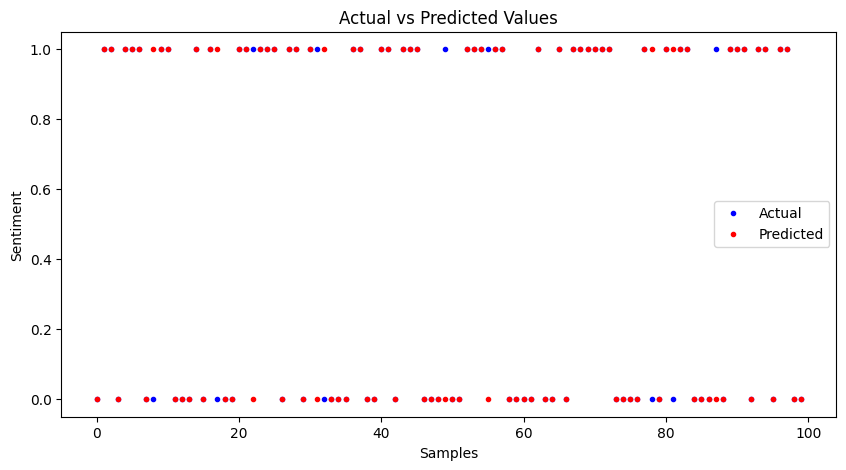

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(y_test[:100], 'b.', label='Actual')

plt.plot(y_pred[:100], 'r.', label='Predicted')

plt.title('Actual vs Predicted Values')

plt.xlabel('Samples')

plt.ylabel('Sentiment')

plt.legend()

plt.show()

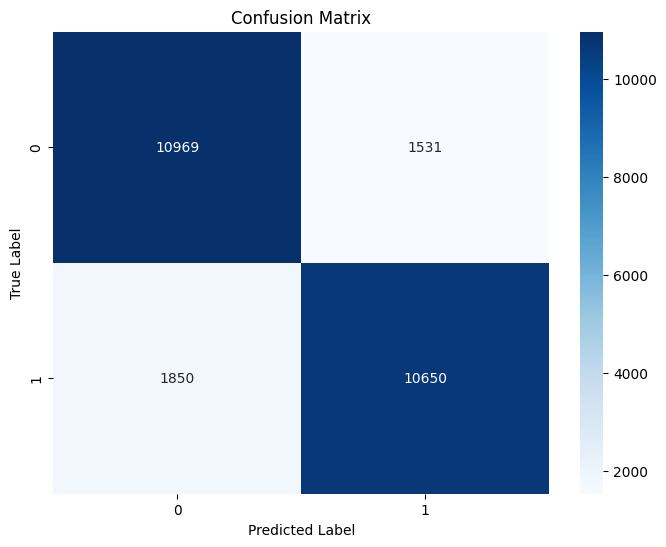

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87     12500
           1       0.87      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [10]:
cm = confusion_matrix(y_test, y_pred)

classification_rep = classification_report(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted Label')

plt.ylabel('True Label')

plt.show()

print("Classification Report:\n", classification_rep)